In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
movies = pd.read_csv("TMDB_movie_dataset_v11.csv", on_bad_lines='skip', engine='python')

In [8]:
movies.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [9]:
movies.shape

(1237978, 24)

In [10]:
movies.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='object')

In [11]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237978 entries, 0 to 1237977
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1237978 non-null  int64  
 1   title                 1237961 non-null  object 
 2   vote_average          1237978 non-null  float64
 3   vote_count            1237978 non-null  int64  
 4   status                1237978 non-null  object 
 5   release_date          958612 non-null   object 
 6   revenue               1237978 non-null  int64  
 7   runtime               1237978 non-null  int64  
 8   adult                 1237978 non-null  bool   
 9   backdrop_path         321914 non-null   object 
 10  budget                1237978 non-null  int64  
 11  homepage              128351 non-null   object 
 12  imdb_id               603473 non-null   object 
 13  original_language     1237978 non-null  object 
 14  original_title        1237960 non-

In [12]:
cols_to_drop = ['adult', 'backdrop_path', 'poster_path', 'homepage',
                'imdb_id', 'budget', 'revenue', 'runtime', 'tagline',
                'production_companies', 'production_countries',
                'spoken_languages', 'status', 'original_title']

movies = movies.drop(columns=cols_to_drop)
print(movies.columns)
print(movies.shape)

Index(['id', 'title', 'vote_average', 'vote_count', 'release_date',
       'original_language', 'overview', 'popularity', 'genres', 'keywords'],
      dtype='object')
(1237978, 10)


In [13]:
movies.isnull().sum()

,0
id,0
title,17
vote_average,0
vote_count,0
release_date,279366
original_language,0
overview,282350
popularity,1
genres,536211
keywords,916652


In [14]:
# Step 1 — Drop rows where overview is null
movies = movies.dropna(subset=['overview'])

# Step 2 — Fill remaining nulls
movies['vote_average'] = movies['vote_average'].fillna(movies['vote_average'].mean())
movies['original_language'] = movies['original_language'].fillna('en')
movies['popularity'] = movies['popularity'].fillna(movies['popularity'].median())
movies['keywords'] = movies['keywords'].fillna('')
movies['genres'] = movies['genres'].fillna('')

# Step 3 — Reset index
movies = movies.reset_index(drop=True)

# Step 4 — Check nulls again
print(movies.isnull().sum())
print(f"\nFinal shape: {movies.shape}")

id                        0
title                     6
vote_average              0
vote_count                0
release_date         165242
original_language         0
overview                  0
popularity                0
genres                    0
keywords                  0
dtype: int64

Final shape: (955628, 10)


In [15]:
movies = movies.drop(columns=['release_date'])
print(movies.columns)

Index(['id', 'title', 'vote_average', 'vote_count', 'original_language',
       'overview', 'popularity', 'genres', 'keywords'],
      dtype='object')


In [16]:
movies.isnull().sum()

,0
id,0
title,6
vote_average,0
vote_count,0
original_language,0
overview,0
popularity,0
genres,0
keywords,0


In [17]:
movies = movies.dropna(subset=['title'])
print(f"Final shape: {movies.shape}")
print(movies.isnull().sum())

Final shape: (955622, 9)
id                   0
title                0
vote_average         0
vote_count           0
original_language    0
overview             0
popularity           0
genres               0
keywords             0
dtype: int64


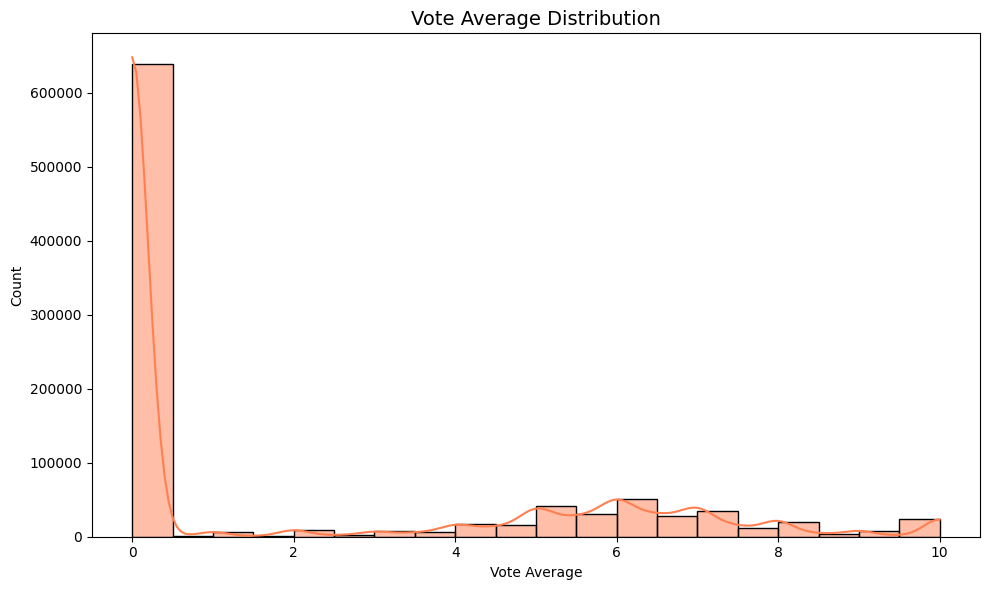

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(movies['vote_average'], bins=20, kde=True, color='coral', ax=ax)
ax.set_title('Vote Average Distribution', fontsize=14)
ax.set_xlabel('Vote Average')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8558/2612237868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma', ax=ax)


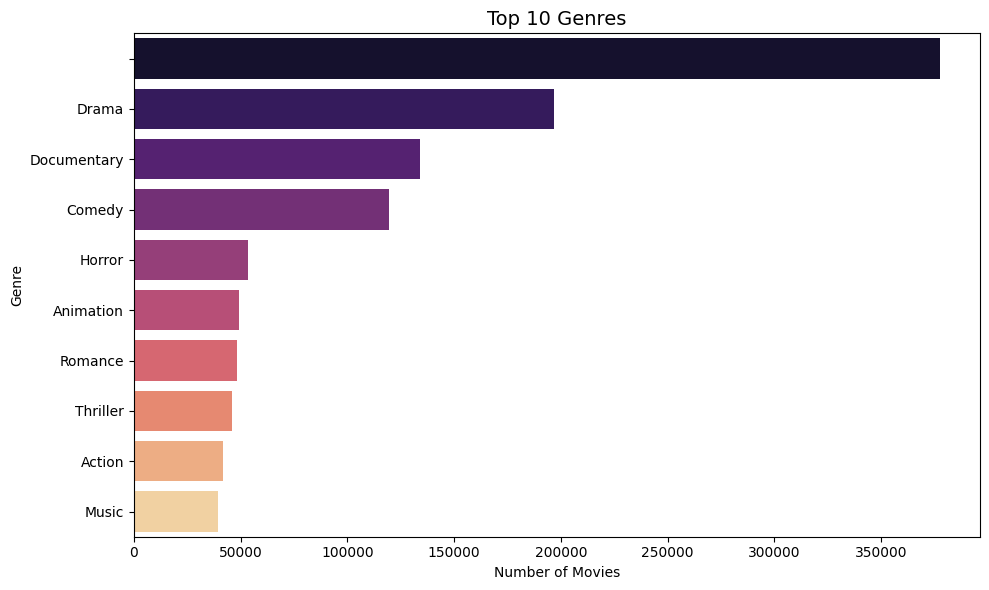

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
genre_list = movies['genres'].str.split(',').explode().str.strip()
genre_counts = genre_list.value_counts().head(10)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='magma', ax=ax)
ax.set_title('Top 10 Genres', fontsize=14)
ax.set_xlabel('Number of Movies')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

In [20]:
movies.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'original_language',
       'overview', 'popularity', 'genres', 'keywords'],
      dtype='object')

In [23]:
movies['tags'] = (
    movies['genres'] + ' ' +
    movies['keywords'] + ' ' +
    movies['original_language'] + ' ' +
    movies['overview']
)

# Convert to lowercase
movies['tags'] = movies['tags'].str.lower()

# Check
print(movies['tags'].head(3))

0    action, science fiction, adventure rescue, mis...
1    adventure, drama, science fiction rescue, futu...
2    drama, action, crime, thriller joker, sadism, ...
Name: tags, dtype: object


In [24]:
movies.head()

,id,title,vote_average,vote_count,original_language,overview,popularity,genres,keywords,tags
0,27205,Inception,8.364,34495,en,"Cobb, a skilled thief who commits corporate es...",83.952,"Action, Science Fiction, Adventure","rescue, mission, dream, airplane, paris, franc...","action, science fiction, adventure rescue, mis..."
1,157336,Interstellar,8.417,32571,en,The adventures of a group of explorers who mak...,140.241,"Adventure, Drama, Science Fiction","rescue, future, spacecraft, race against time,...","adventure, drama, science fiction rescue, futu..."
2,155,The Dark Knight,8.512,30619,en,Batman raises the stakes in his war on crime. ...,130.643,"Drama, Action, Crime, Thriller","joker, sadism, chaos, secret identity, crime f...","drama, action, crime, thriller joker, sadism, ..."
3,19995,Avatar,7.573,29815,en,"In the 22nd century, a paraplegic Marine is di...",79.932,"Action, Adventure, Fantasy, Science Fiction","future, society, culture clash, space travel, ...","action, adventure, fantasy, science fiction fu..."
4,24428,The Avengers,7.710,29166,en,When an unexpected enemy emerges and threatens...,98.082,"Science Fiction, Action, Adventure","new york city, superhero, shield, based on com...","science fiction, action, adventure new york ci..."


In [25]:
movies.shape

(955622, 10)

In [27]:
new_df = movies[['id', 'title', 'genres', 'overview', 'tags']]
print(new_df.shape)

(955622, 5)


In [17]:
new_df=new_df.drop(columns=['genre','overview'])
new_df.head()

,id,title,tags
0,278,The Shawshank Redemption,"Drama,CrimeFramed in the 1940s for the double ..."
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,RomanceRaj is a rich, carefree, h..."
2,238,The Godfather,"Drama,CrimeSpanning the years 1945 to 1955, a ..."
3,424,Schindler's List,"Drama,History,WarThe true story of how busines..."
4,240,The Godfather: Part II,"Drama,CrimeIn the continuing saga of the Corle..."


In [34]:
new_df.head()

,id,title,tags
0,278,The Shawshank Redemption,drama crime drama crime en en framed in the 19...
1,19404,Dilwale Dulhania Le Jayenge,comedy drama romance comedy drama romance hi h...
2,238,The Godfather,drama crime drama crime en en spanning the yea...
3,424,Schindler's List,drama history war drama history war en en the ...
4,240,The Godfather: Part II,drama crime drama crime en en in the continuin...


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))

# ✅ NO .toarray() — keep sparse matrix!
vec = tfidf.fit_transform(new_df['tags'])
print(vec.shape)

(955622, 5000)


In [30]:
from sklearn.metrics.pairwise import cosine_similarity

In [31]:
index = new_df[new_df['title'] == 'The Dark Knight'].index[0]
print(index)

2


In [32]:
sim_scores = cosine_similarity(vec[index], vec).flatten()
print(sim_scores.shape)

(955622,)


In [33]:
distance = sorted(list(enumerate(sim_scores)), reverse=True, key=lambda x: x[1])
print(distance[:5])

[(2, np.float64(1.0)), (487, np.float64(0.49493722590493666)), (879, np.float64(0.45635531275602753)), (4036, np.float64(0.38368992314606687)), (189458, np.float64(0.37825451551456524))]


In [34]:
print("Top 5 movies similar to 'The Dark Knight':")
for i in distance[1:6]:
    print(new_df.iloc[i[0]].title)

Top 5 movies similar to 'The Dark Knight':
Batman
Batman Forever
Batman: Mask of the Phantasm
Star Reporter
Wives Under Suspicion


In [36]:
def recommend(movie):
    matches = new_df[new_df['title'] == movie]
    if matches.empty:
        print(f"Movie '{movie}' not found!")
        return

    index = matches.index[0]
    sim_scores = cosine_similarity(vec[index], vec).flatten()
    distance = sorted(list(enumerate(sim_scores)), reverse=True, key=lambda x: x[1])

    print(f"\nTop 5 movies similar to '{movie}':")
    for i in distance[1:6]:
        print(new_df.iloc[i[0]].title)

In [37]:
recommend('The Dark Knight')


Top 5 movies similar to 'The Dark Knight':
Batman
Batman Forever
Batman: Mask of the Phantasm
Star Reporter
Wives Under Suspicion


In [38]:
recommend('Dilwale Dulhania Le Jayenge')


Top 5 movies similar to 'Dilwale Dulhania Le Jayenge':
Rakhi Aur Hathkadi
Chhoti Chhoti Baatein
Bond
Omah Omah
Du und ich
